In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [15]:
df = pd.read_csv('uber.csv')

# Displaying the first few rows
print("Dataset Head:")
display(df.head())

# Checking dataset info
print("\nDataset Information:")
df.info()

# Checking summary statistics
print("\nSummary Statistics:")
display(df.describe())

Dataset Head:


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB

Summary Statistics:


,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [16]:
df = df.dropna()
df = df[df['fare_amount'] > 0]

In [17]:
def distance(lat1, lon1, lat2, lon2):
    return np.sqrt((lat1 - lat2)**2 + (lon1 - lon2)**2)

df['distance'] = distance(
    df['pickup_latitude'],
    df['pickup_longitude'],
    df['dropoff_latitude'],
    df['dropoff_longitude']
)

In [18]:
from sklearn.model_selection import train_test_split

# Defining features and target
X = df[['distance']]
y = df['fare_amount']

# Splitting the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 159981
Testing set size: 39996


In [19]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


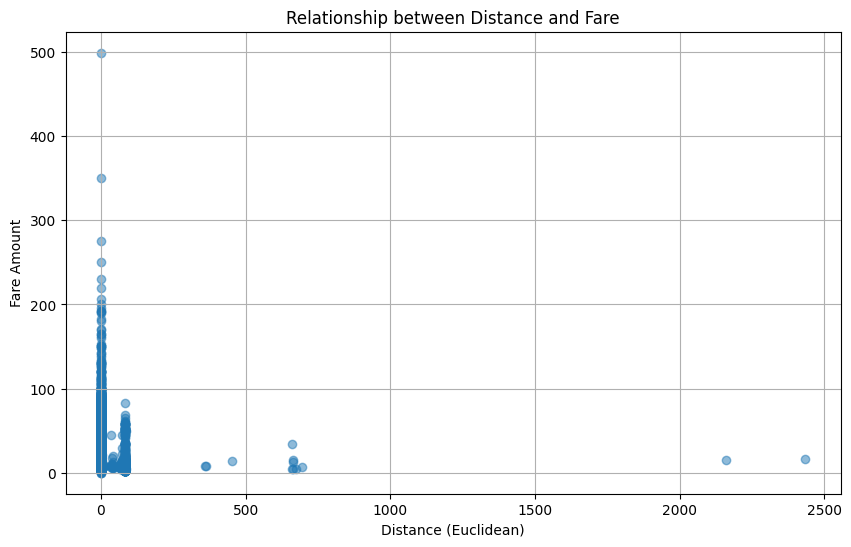

In [20]:
# Recalculate distance to ensure it exists in the current df
def calculate_distance(lat1, lon1, lat2, lon2):
    return np.sqrt((lat1 - lat2)**2 + (lon1 - lon2)**2)

df['distance'] = calculate_distance(
    df['pickup_latitude'],
    df['pickup_longitude'],
    df['dropoff_latitude'],
    df['dropoff_longitude']
)

# Plotting Distance vs Fare
plt.figure(figsize=(10, 6))
plt.scatter(df['distance'], df['fare_amount'], alpha=0.5)
plt.xlabel("Distance (Euclidean)")
plt.ylabel("Fare Amount")
plt.title("Relationship between Distance and Fare")
plt.grid(True)
plt.show()

### Visualizing the Data
We will create a histogram of the fares and a scatter plot of distance vs. fare.

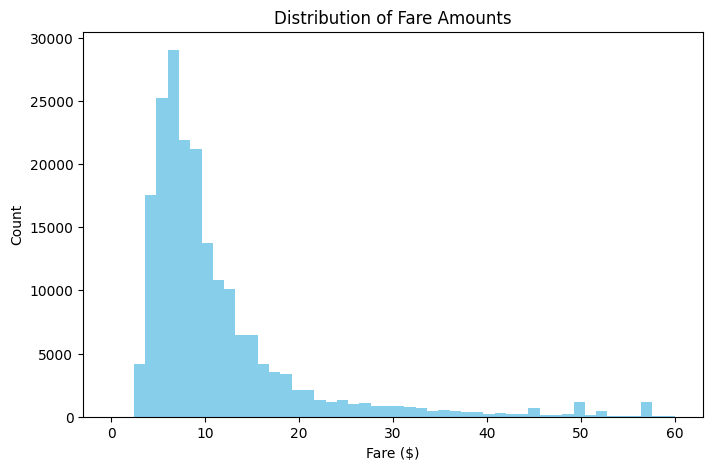

In [21]:
# 1. Simple Fare Distribution
plt.figure(figsize=(8, 5))
plt.hist(df['fare_amount'], bins=50, range=(0, 60), color='skyblue')
plt.title('Distribution of Fare Amounts')
plt.xlabel('Fare ($)')
plt.ylabel('Count')
plt.show()

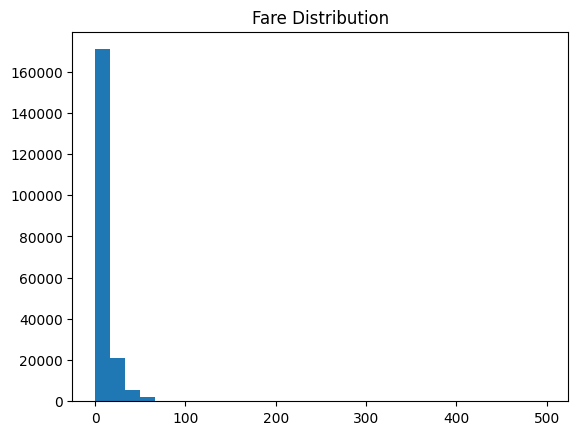

In [22]:
# Fare distribution
plt.figure()
plt.hist(df['fare_amount'], bins=30)
plt.title("Fare Distribution")
plt.show()

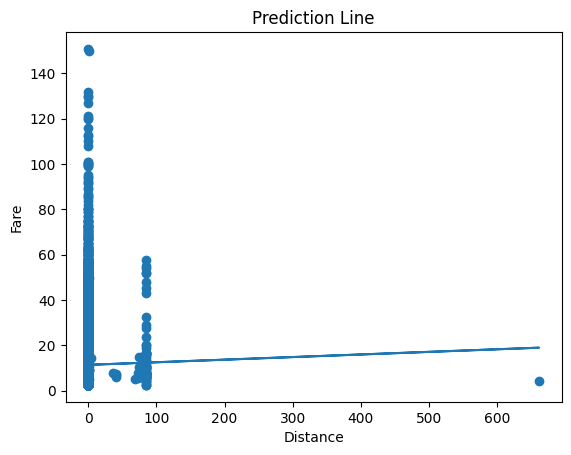

In [23]:
y_pred = model.predict(X_test)

plt.figure()
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)   # regression line
plt.xlabel("Distance")
plt.ylabel("Fare")
plt.title("Prediction Line")
plt.show()

In [24]:
distance = float(input("Enter distance in km: "))

predicted_fare = model.predict([[distance]])

print("Predicted fare:", predicted_fare[0])

Enter distance in km: 10
Predicted fare: 11.470035077296476


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [25]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 9.642284704967945
R2 Score: 0.0001516903339982001


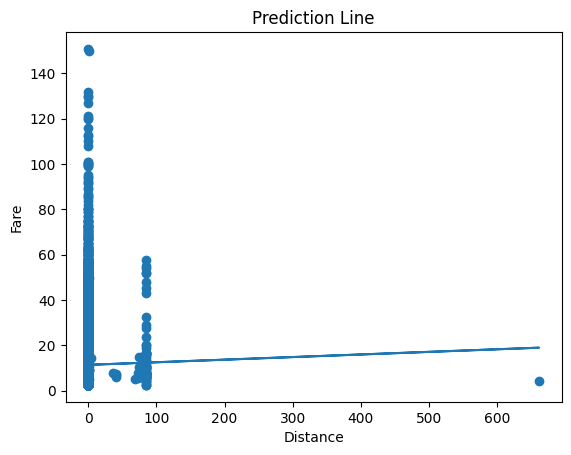

In [26]:
plt.figure()
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.xlabel("Distance")
plt.ylabel("Fare")
plt.title("Prediction Line")
plt.show()

In [27]:
import joblib

# Save the model to a .pkl file
model_filename = 'linear_regression_model.pkl'
joblib.dump(model, model_filename)

print(f"Model saved successfully as {model_filename}")

Model saved successfully as linear_regression_model.pkl
